# StockSight - 02 · Classical ML Results

Regression models predicting the **1-day forward return**: **Ridge**, **Random Forest**, **XGBoost**,
plus `naive_zero` / `naive_persistence` baselines. Everything here is **loaded from precomputed
results** (`results/ml_summary.csv`, `results/predictions_ml.parquet`) - no training runs in the notebook.

In [1]:
# === Setup (shared across the StockSight notebook suite) ===
import sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# Locate the project root (the folder that holds config.yaml) and put it on sys.path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.yaml").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({"figure.figsize": (11, 4), "figure.dpi": 110})
sns.set_style("whitegrid")
sns.set_palette("deep")
HEATMAP_CMAP = "RdBu_r"
SEED = 42

from src.config import RESULTS_DIR, MODELS_DIR, CFG

print("Project root :", ROOT)
print("Universe     :", len(CFG["tickers"]), "tickers ->", ", ".join(CFG["tickers"]))

Project root : F:\AIProjects\stocksight
Universe     : 21 tickers -> NDSN, HON, BKR, APA, CSX, JBHT, FAST, FELE, GT, FITB, NTRS, EA, AEP, AMGN, COST, ROST, PEP, KMB, MAT, HAS, NWL


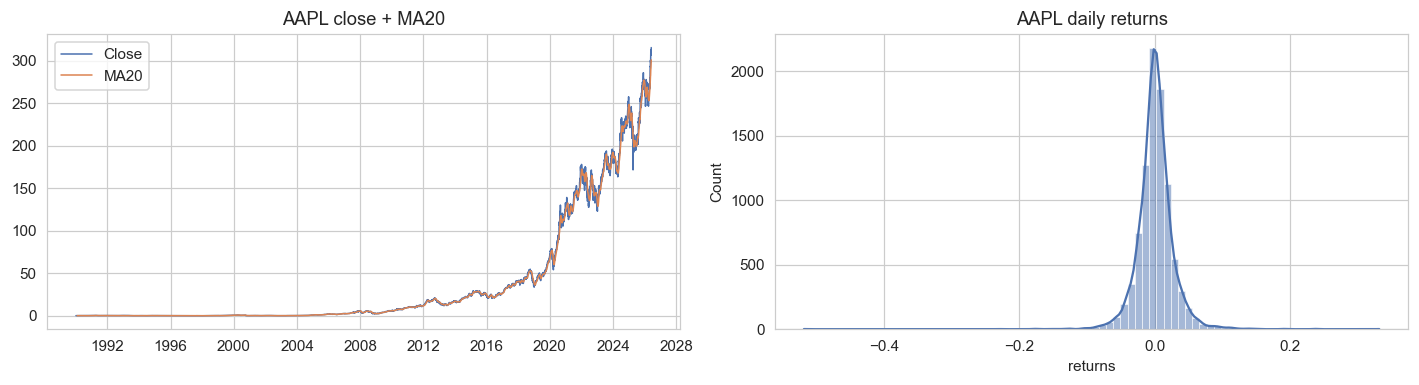

Recap exemplar: AAPL | rows=9171 | 1990-01-02 -> 2026-06-02
Modeled universe: 21 tickers (AAPL excluded)


In [2]:
# === Shared data recap (same code in 02 / 03 / 04) ===
# EDA exemplar = AAPL (see 01_eda for the full analysis). The MODELED UNIVERSE is the
# 21 tickers in config.yaml (AAPL is not among them), so model/eval visuals below use a
# universe ticker. yfinance is only needed for the AAPL fetch; results files are local.
from src.data_loader import load_stock

EDA_TICKER = "AAPL"
try:
    _eda = load_stock(EDA_TICKER)
except Exception as exc:  # offline / fetch failure -> fall back to a cached universe name
    EDA_TICKER = "COST"
    _eda = load_stock(EDA_TICKER)
    print(f"(AAPL fetch failed: {exc}; recap falls back to {EDA_TICKER})")

_eda = _eda.sort_values("date").reset_index(drop=True)
_eda["ma_20"] = _eda["close"].rolling(20).mean()
_eda["returns"] = _eda["close"].pct_change()

fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
ax[0].plot(_eda["date"], _eda["close"], lw=1, label="Close")
ax[0].plot(_eda["date"], _eda["ma_20"], lw=1, label="MA20")
ax[0].set_title(f"{EDA_TICKER} close + MA20"); ax[0].legend()
sns.histplot(_eda["returns"].dropna(), bins=80, kde=True, ax=ax[1])
ax[1].set_title(f"{EDA_TICKER} daily returns")
plt.tight_layout(); plt.show()

print(f"Recap exemplar: {EDA_TICKER} | rows={len(_eda)} | "
      f"{_eda['date'].min().date()} -> {_eda['date'].max().date()}")
print(f"Modeled universe: {len(CFG['tickers'])} tickers (AAPL excluded)")
UNIVERSE_TICKER = "COST"  # exemplar used wherever precomputed predictions/models are needed

## 1 · Approach - how the ML models are set up

**Why classical ML first.** Before reaching for deep learning, we establish a strong, interpretable,
fast-to-train baseline. If simple models already capture the signal, the extra complexity of a neural
network is not justified; if they do not, the deep model has a clear bar to beat. Classical models also
train in seconds, so we can sweep all 21 tickers and report honest cross-sectional metrics.

**Task.** Each model predicts the **next-day return** `y_return` (tomorrow's % change), one ticker at a
time, across the 21-name universe. We model the **return** (roughly stationary and comparable across
tickers) rather than the raw price, and keep it a **regression** rather than an up/down classification so
the *magnitude* of the signal is preserved for the downstream backtest.

**Pipeline (leakage-free):**
- **Features** → ~18 technical indicators (returns, moving averages, RSI, MACD, volatility, Bollinger width, volume) + 4 macro changes (VIX, 10Y yield, oil, USD) + sector-correlation features.
- **Scaling** → `MinMaxScaler` fit **only on the training slice**, then applied to validation/test.
- **Split** → strictly **chronological 85 / 15** (no shuffling - the past predicts the future); the last 10% of training is held out for validation.
- **Baselines** → `naive_zero` (always predict 0) and `naive_persistence` (predict yesterday's return) set the bar every model must clear.

**What each model contributes:**
- **Ridge** - a regularised linear model; captures the linear factor exposure (how returns load on the technical and macro features) and is the most robust when signal-to-noise is low.
- **Random Forest (`rf_reg`)** - an ensemble of decision trees; captures non-linear effects and feature interactions (e.g. the return-vs-VIX fan-out from notebook 01) and needs no scaling.
- **XGBoost (`xgb_reg`)** - gradient-boosted trees; usually the strongest tabular learner, but also the most prone to over-fit when the underlying signal is weak.
- **Naive baselines** - the honesty check: any model that cannot beat `naive_zero` / `naive_persistence` is not adding value.

**How we judge them.** Error (MAE, RMSE), the **MAE-vs-naive ratio** (better than predicting zero?), **R²**
(does it explain any variance?), and **directional accuracy** (does it get up-vs-down right?).
Hyperparameters come straight from `config.yaml`, printed below.

In [3]:
import json
print(json.dumps(CFG["ml"], indent=2))

{
  "ridge": {
    "alpha": 1.0
  },
  "logistic": {
    "max_iter": 1000,
    "class_weight": "balanced"
  },
  "random_forest": {
    "n_estimators": 200,
    "max_depth": 6,
    "min_samples_split": 5,
    "class_weight": "balanced"
  },
  "xgboost": {
    "n_estimators": 300,
    "max_depth": 6,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8
  }
}


## 2 · Per-ticker results

Two views of the same 21 × 3 grid (rows = tickers, columns = models):
- **Test MAE** - average size of the daily-return prediction error (lower is better).
- **Directional accuracy** - how often the model gets the *sign* right (up vs down). 0.50 = coin flip.

In [4]:
ml = pd.read_csv(RESULTS_DIR / "ml_summary.csv")
reg_models = ["ridge", "rf_reg", "xgb_reg"]
ml_reg = ml[ml["model"].isin(reg_models)]

mae_pivot = ml_reg.pivot(index="ticker", columns="model", values="test_mae_return")
print("Test MAE (1-day return) - ticker x model")
display(mae_pivot.round(4))

dir_pivot = ml_reg.pivot(index="ticker", columns="model", values="directional_accuracy")
print("Directional accuracy - ticker x model")
display(dir_pivot.round(3))

Test MAE (1-day return) - ticker x model


model,rf_reg,ridge,xgb_reg
ticker,,,
AEP,0.0075,0.0078,0.0088
AMGN,0.0115,0.0116,0.0120
APA,0.0134,0.0134,0.0143
BKR,0.0139,0.0140,0.0149
COST,0.0119,0.0076,0.0121
CSX,0.0115,0.0114,0.0124
EA,0.0183,0.0163,0.0173
FAST,0.0122,0.0117,0.0147
FELE,0.0132,0.0131,0.0145


Directional accuracy - ticker x model


model,rf_reg,ridge,xgb_reg
ticker,,,
AEP,0.538,0.473,0.481
AMGN,0.480,0.493,0.501
APA,0.490,0.489,0.490
BKR,0.494,0.496,0.474
COST,0.486,0.514,0.484
CSX,0.458,0.465,0.487
EA,0.509,0.477,0.480
FAST,0.486,0.484,0.503
FELE,0.521,0.503,0.489


## 3 · Aggregate model comparison - the honest headline

Averages across all 21 tickers. **This is the key slide for the ML story:**

| Model | Directional accuracy | MAE vs naive | R² |
|---|---|---|---|
| Ridge | ~0.49 | ~1.04 | negative |
| Random Forest | ~0.50 | ~1.12 | negative |
| XGBoost | ~0.49 | ~1.24 | negative |

- **Directional accuracy ≈ 0.49-0.50** → essentially a coin flip.
- **MAE-vs-naive > 1** → *worse* on raw error than just predicting "zero return".
- **R² < 0** → explains none of the day-to-day variance.

Next-day returns are dominated by noise - no classical model beats the naive baseline. This isn't a tuning failure; it's the efficient-market reality, and being honest about it is what makes the later backtest credible. The red dashed lines mark the 0.50 (accuracy) and 1.0 (naive) break-even points.

,test_mae_return,directional_accuracy,mae_vs_naive_ratio,r2_score
model,,,,
ridge,0.0109,0.4878,1.0347,-0.0491
rf_reg,0.0117,0.5036,1.1166,-0.2546
xgb_reg,0.0129,0.4917,1.2442,-0.4697


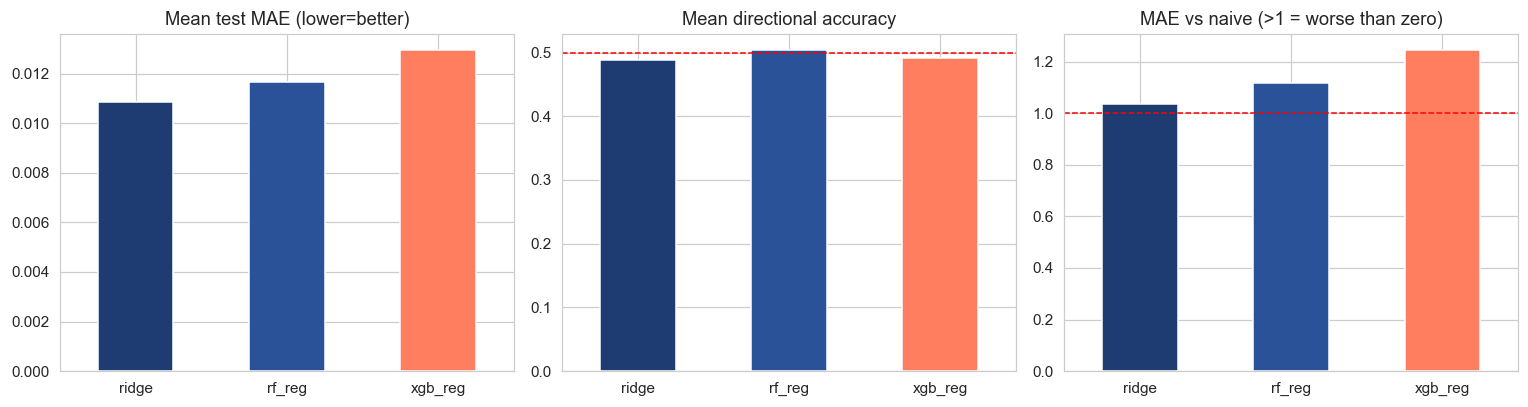

In [5]:
agg = (ml_reg.groupby("model")[["test_mae_return", "directional_accuracy",
                                "mae_vs_naive_ratio", "r2_score"]]
       .mean().reindex(reg_models))
display(agg.round(4))

C = ["#1e3c72", "#2a5298", "#ff7e5f"]
fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
agg["test_mae_return"].plot(kind="bar", ax=ax[0], color=C)
ax[0].set_title("Mean test MAE (lower=better)")
agg["directional_accuracy"].plot(kind="bar", ax=ax[1], color=C)
ax[1].axhline(0.5, color="red", ls="--", lw=1); ax[1].set_title("Mean directional accuracy")
agg["mae_vs_naive_ratio"].plot(kind="bar", ax=ax[2], color=C)
ax[2].axhline(1.0, color="red", ls="--", lw=1); ax[2].set_title("MAE vs naive (>1 = worse than zero)")
for a in ax:
    a.set_xlabel(""); a.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

## 4 · Directional accuracy heatmap

The same numbers as a colour grid (`RdYlGn` centred on 0.50): **green = beats a coin flip, red = below it.**

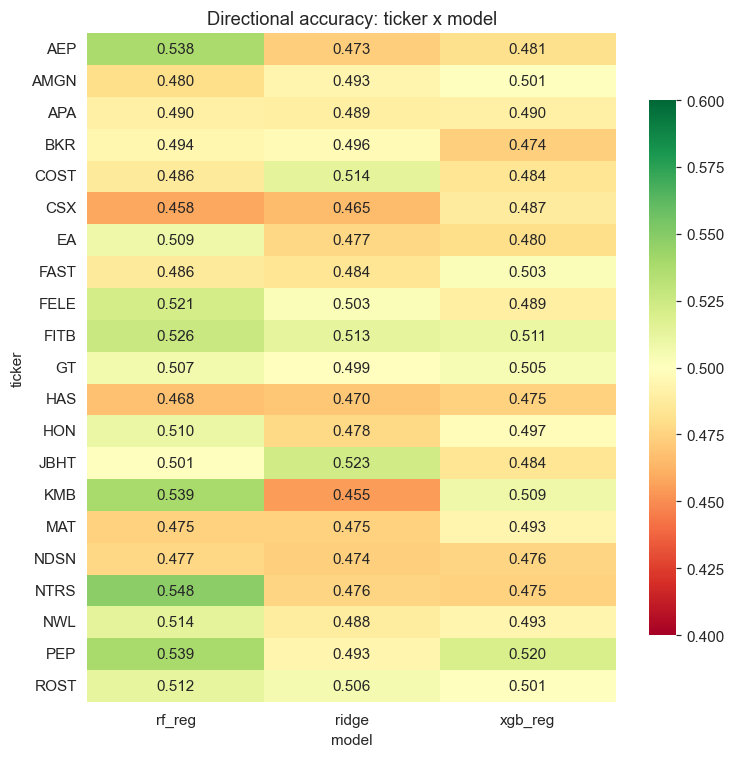

In [6]:
plt.figure(figsize=(7, 7))
sns.heatmap(dir_pivot, annot=True, fmt=".3f", cmap="RdYlGn", center=0.5,
            vmin=0.40, vmax=0.60, cbar_kws={"shrink": 0.8})
plt.title("Directional accuracy: ticker x model")
plt.tight_layout(); plt.show()

## 5 · Best model per ticker

For each name, the model with the **lowest test MAE**. The `model counts` line shows which model "wins" most often.

Even the per-ticker winners sit right at the noise floor - 'best' here means 'least bad', not 'good'. Handy to pre-empt the *so which model should I use?* question.

In [7]:
best = (ml_reg.loc[ml_reg.groupby("ticker")["test_mae_return"].idxmin()]
        [["ticker", "model", "test_mae_return", "directional_accuracy", "r2_score"]]
        .set_index("ticker").sort_index())
display(best.round(4))
print("model counts:", best["model"].value_counts().to_dict())

,model,test_mae_return,directional_accuracy,r2_score
ticker,,,,
AEP,rf_reg,0.0075,0.5376,-0.0043
AMGN,rf_reg,0.0115,0.4799,-0.0370
APA,rf_reg,0.0134,0.4902,-0.0192
BKR,rf_reg,0.0139,0.4943,-0.0090
COST,ridge,0.0076,0.5139,-0.0700
CSX,ridge,0.0114,0.4655,-0.0393
EA,ridge,0.0163,0.4768,-0.0194
FAST,ridge,0.0117,0.4840,-0.0588
FELE,ridge,0.0131,0.5026,-0.0181


model counts: {'ridge': 11, 'rf_reg': 10}


## 6 · Predicted vs actual returns (exemplar: COST)

Test-window predictions for one universe ticker.
- **Left** - predicted (orange) vs realised (blue) daily return over time.
- **Right** - scatter of predicted vs actual.

The predicted line is **far flatter** than the real one - the model hedges toward zero (classic regression shrinkage under low signal). The scatter is a near-vertical cloud: little link between predicted and actual magnitude.

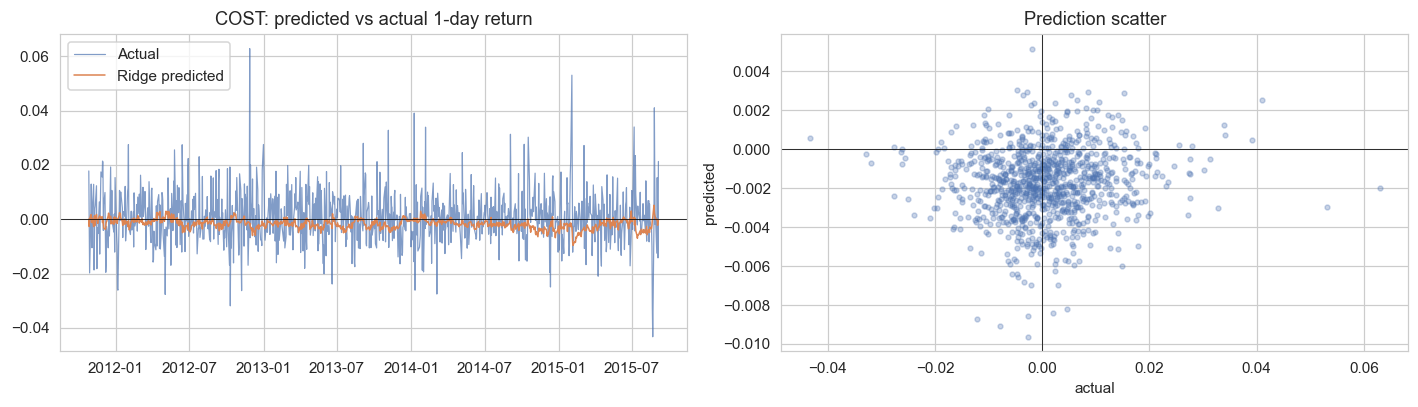

COST ridge directional accuracy (test): 0.514


In [8]:
pred_ml = pd.read_parquet(RESULTS_DIR / "predictions_ml.parquet")
sub = pred_ml[(pred_ml["ticker"] == UNIVERSE_TICKER) & (pred_ml["model"] == "ridge")].copy()
sub["date"] = pd.to_datetime(sub["date"])
sub = sub.sort_values("date")

fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
ax[0].plot(sub["date"], sub["y_true_return"], lw=0.8, alpha=0.7, label="Actual")
ax[0].plot(sub["date"], sub["y_pred_return"], lw=1, label="Ridge predicted")
ax[0].axhline(0, color="black", lw=0.5)
ax[0].set_title(f"{UNIVERSE_TICKER}: predicted vs actual 1-day return"); ax[0].legend()

ax[1].scatter(sub["y_true_return"], sub["y_pred_return"], alpha=0.3, s=10)
ax[1].axhline(0, color="black", lw=0.5); ax[1].axvline(0, color="black", lw=0.5)
ax[1].set_xlabel("actual"); ax[1].set_ylabel("predicted")
ax[1].set_title("Prediction scatter")
plt.tight_layout(); plt.show()

dir_acc = float((np.sign(sub["y_pred_return"]) == np.sign(sub["y_true_return"])).mean())
print(f"{UNIVERSE_TICKER} ridge directional accuracy (test): {dir_acc:.3f}")

## 7 · Feature importance (COST Random Forest)

Top-15 features by Random-Forest importance, read from the **saved model** (loaded, not retrained).

Importance is spread across momentum (RSI/MACD), volatility and macro-change features rather than dominated by one variable - the model combines many weak signals, none individually decisive.

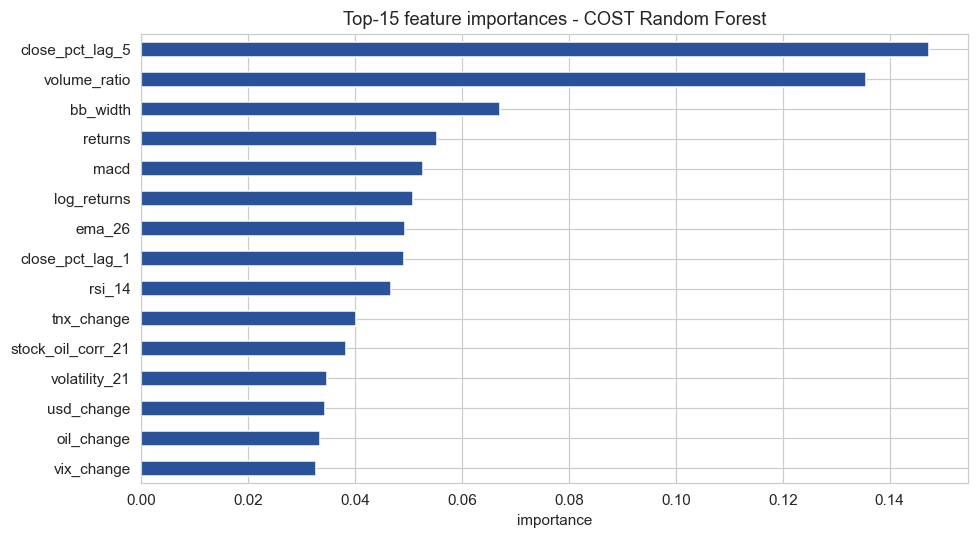

In [9]:
import joblib
from src.features import feature_columns

rf = joblib.load(MODELS_DIR / f"{UNIVERSE_TICKER}_rf_reg.pkl")
feat_names = feature_columns(UNIVERSE_TICKER)
fi = pd.Series(rf.feature_importances_, index=feat_names).sort_values()

plt.figure(figsize=(9, 5))
fi.tail(15).plot(kind="barh", color="#2a5298")
plt.title(f"Top-15 feature importances - {UNIVERSE_TICKER} Random Forest")
plt.xlabel("importance"); plt.tight_layout(); plt.show()

## 8 · Takeaways

- **All three regressors are statistically tied** and all sit at/under the naive baseline - next-day point returns are essentially unpredictable here.
- **Directional accuracy ~0.50** says point-return regression is the wrong lens; what matters downstream is whether even a faint *sign* signal is tradeable after costs.
- **Feature importances** spread across momentum, volatility and macro features - many weak signals, no silver bullet.

Classical ML on a 1-day horizon is near-random. Does framing the problem as a *14-day directional sequence* with deep learning do better? → **`03_dl`**.